# PART 14

Haikal Ali_1103223071_TK46GAB

# Chapter 14 — Singular Value Decomposition


## Singular Value Decomposition



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.linalg import null_space

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(42)

## SVD di Python

Di NumPy, SVD dihitung dengan:

```python
U, s, Vt = np.linalg.svd(A)
```

NumPy mengembalikan singular values sebagai vektor `s`, bukan matriks \(\Sigma\). Karena itu, untuk membentuk \(\Sigma\), dibuat matriks nol seukuran `A`, lalu diagonalnya diisi dengan `s`.

In [2]:
A = rng.normal(size=(4, 6))

U, s, Vt = np.linalg.svd(A, full_matrices=True)

S = np.zeros(A.shape)
np.fill_diagonal(S, s)

A_recon = U @ S @ Vt

print("Shape A :", A.shape)
print("Shape U :", U.shape)
print("Shape S :", S.shape)
print("Shape Vt:", Vt.shape)
print("Singular values:", s)
print("Error rekonstruksi:", np.linalg.norm(A - A_recon))
print("U.T @ U mendekati I:", np.allclose(U.T @ U, np.eye(U.shape[1])))
print("Vt @ Vt.T mendekati I:", np.allclose(Vt @ Vt.T, np.eye(Vt.shape[0])))

Shape A : (4, 6)
Shape U : (4, 4)
Shape S : (4, 6)
Shape Vt: (6, 6)
Singular values: [3.3073 1.8321 1.3052 0.6528]
Error rekonstruksi: 1.8951820233255605e-15
U.T @ U mendekati I: True
Vt @ Vt.T mendekati I: True


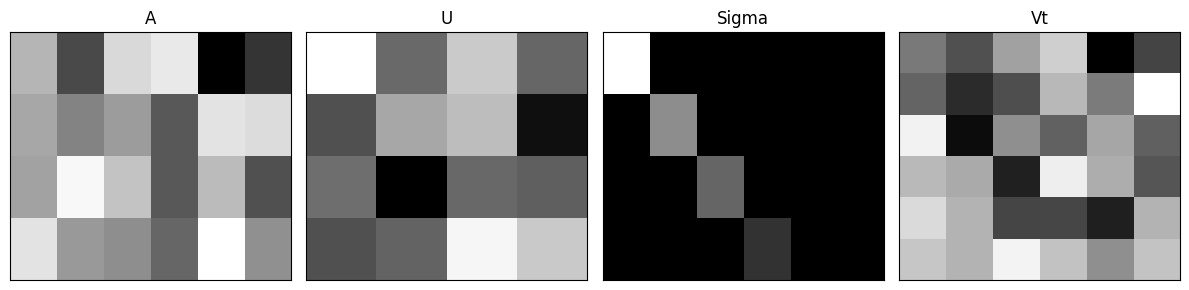

In [3]:
fig, axs = plt.subplots(1, 4, figsize=(12, 3))

mats = [A, U, S, Vt]
titles = ["A", "U", "Sigma", "Vt"]

for ax, M, title in zip(axs, mats, titles):
    ax.imshow(M, aspect="auto", cmap="gray")
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## Singular Values dan Rank Matriks

Rank matriks dapat dipahami sebagai jumlah singular value yang tidak nol. Dalam komputasi numerik, Python tidak benar-benar mengecek `tidak nol`, tetapi mengecek apakah singular value lebih besar dari suatu nilai toleransi kecil.

In [4]:
A = rng.normal(size=(6, 4))
s = np.linalg.svd(A, compute_uv=False)

tol = s.max() * max(A.shape) * np.finfo(float).eps
rank_manual = np.count_nonzero(s > tol)

print("Singular values:", s)
print("Tolerance:", tol)
print("Rank manual:", rank_manual)
print("Rank NumPy :", np.linalg.matrix_rank(A))

Singular values: [2.7145 2.0278 0.9086 0.3767]
Tolerance: 3.61638986568997e-15
Rank manual: 4
Rank NumPy : 4


## SVD sebagai Lapisan Rank-1

SVD juga dapat dilihat sebagai penjumlahan beberapa matriks rank-1:

\[
A = \sum_{i=1}^{r} u_i \sigma_i v_i^T
\]

Setiap lapisan rank-1 dibuat dari outer product antara left singular vector dan right singular vector, lalu dikalikan dengan singular value yang sesuai.

In [5]:
A = rng.normal(size=(5, 4))
U, s, Vt = np.linalg.svd(A, full_matrices=False)

layers = []
for i in range(len(s)):
    layer = np.outer(U[:, i], Vt[i, :]) * s[i]
    layers.append(layer)

A_recon = sum(layers)

print("Rank A:", np.linalg.matrix_rank(A))
print("Jumlah layer:", len(layers))
print("Error rekonstruksi:", np.linalg.norm(A - A_recon))

Rank A: 4
Jumlah layer: 4
Error rekonstruksi: 1.864846294089685e-15


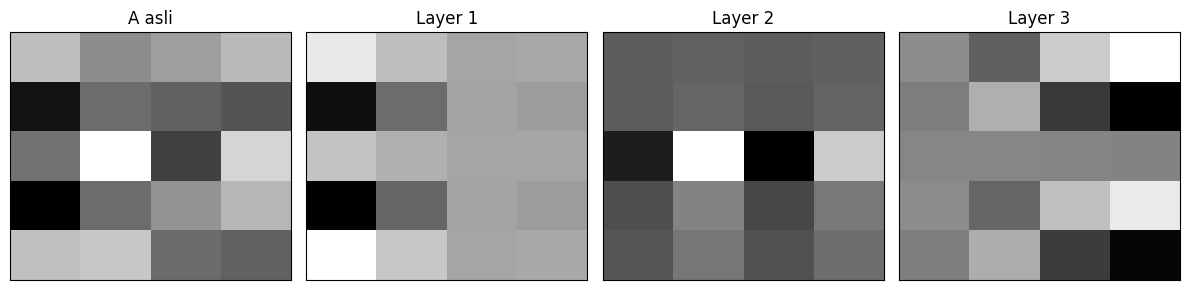

In [6]:
fig, axs = plt.subplots(1, 4, figsize=(12, 3))

axs[0].imshow(A, aspect="auto", cmap="gray")
axs[0].set_title("A asli")

for i in range(3):
    axs[i+1].imshow(layers[i], aspect="auto", cmap="gray")
    axs[i+1].set_title(f"Layer {i+1}")

for ax in axs:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## SVD dari Eigendecomposition

Secara konsep, SVD dapat diperoleh dari eigendecomposition matriks \(AA^T\) dan \(A^TA\).

\[
AA^T = U\Sigma^2U^T
\]

Artinya:
- eigenvectors dari \(AA^T\) adalah left singular vectors dari \(A\),
- eigenvalues dari \(AA^T\) adalah kuadrat singular values dari \(A\).

In [7]:
A = rng.normal(size=(5, 3))

U, s, Vt = np.linalg.svd(A, full_matrices=True)

evals_AAt, evecs_AAt = np.linalg.eigh(A @ A.T)
evals_sorted = np.sort(evals_AAt)[::-1]

print("Singular values^2 dari SVD:")
print(s**2)

print("\nEigenvalues dari A@A.T, urut menurun:")
print(evals_sorted)

print("\nNilai terbesar cocok:", np.allclose(s**2, evals_sorted[:len(s)]))

Singular values^2 dari SVD:
[4.5387 1.892  0.3166]

Eigenvalues dari A@A.T, urut menurun:
[ 4.5387  1.892   0.3166 -0.     -0.    ]

Nilai terbesar cocok: True


## Condition Number

Condition number adalah rasio singular value terbesar terhadap singular value terkecil:
$$
\kappa = \frac{\sigma_{max}}{\sigma_{min}}
$$
Condition number yang besar menunjukkan matriks mendekati singular atau ill-conditioned. Ini dapat membuat inverse atau penyelesaian sistem persamaan menjadi tidak stabil secara numerik.

In [8]:
A = rng.normal(size=(5, 5))
s = np.linalg.svd(A, compute_uv=False)

cond_manual = s.max() / s.min()
cond_numpy = np.linalg.cond(A)

print("Singular values:", s)
print("Condition number manual:", cond_manual)
print("Condition number NumPy :", cond_numpy)

Singular values: [3.1983 1.7254 1.2048 1.1337 0.5071]
Condition number manual: 6.306495947299111
Condition number NumPy : 6.306495947299111


## Moore-Penrose Pseudoinverse

Pseudoinverse dihitung dari SVD dengan membalik singular value yang tidak nol:

\[
A^+ = V\Sigma^+U^T
\]

Jika matriks square dan invertible, pseudoinverse sama dengan inverse. Jika matriks tall full column-rank, pseudoinverse sama dengan left-inverse. Jika matriks wide full row-rank, pseudoinverse sama dengan right-inverse.

In [9]:
def pinv_svd(A, tol=None):
    U, s, Vt = np.linalg.svd(A, full_matrices=False)

    if tol is None:
        tol = max(A.shape) * np.finfo(float).eps * np.max(s)

    s_inv = np.array([1/si if si > tol else 0 for si in s])

    return Vt.T @ np.diag(s_inv) @ U.T

A = rng.normal(size=(5, 3)) @ rng.normal(size=(3, 5))  # rank maksimal 3
A_pinv_manual = pinv_svd(A)
A_pinv_numpy = np.linalg.pinv(A)

print("Rank A:", np.linalg.matrix_rank(A))
print("Jarak manual pinv vs NumPy pinv:", np.linalg.norm(A_pinv_manual - A_pinv_numpy))

Rank A: 3
Jarak manual pinv vs NumPy pinv: 1.9093191206550353e-16


# Code Exercises

## Exercise 14-1

Untuk matriks simetris positif semidefinite seperti \(A^TA\), singular values dan eigenvalues cocok karena eigenvalues tidak negatif.

Untuk matriks simetris dari metode aditif \(A^T + A\), eigenvalues bisa bernilai negatif. Pada kasus itu, singular values cocok dengan nilai absolut eigenvalues, bukan dengan tanda aslinya.

In [10]:
# Bagian 1: matriks simetris positif semidefinite A.T @ A
A = rng.normal(size=(5, 5))
S_psd = A.T @ A

evals, evecs = np.linalg.eigh(S_psd)
U, singvals, Vt = np.linalg.svd(S_psd)

evals_desc = np.sort(evals)[::-1]

print("A.T @ A")
print("Eigenvalues urut menurun:")
print(evals_desc)
print("Singular values:")
print(singvals)
print("Eigenvalues cocok dengan singular values:", np.allclose(evals_desc, singvals))

# Cek kesesuaian arah singular vectors dan eigenvectors
idx = np.argsort(evals)[::-1]
V_eig_sorted = evecs[:, idx]
alignment = np.abs(V_eig_sorted.T @ U)

print("\n|Eigenvectors.T @ SingularVectors|:")
print(alignment)

A.T @ A
Eigenvalues urut menurun:
[26.5413  5.9081  2.4245  1.6442  0.0077]
Singular values:
[26.5413  5.9081  2.4245  1.6442  0.0077]
Eigenvalues cocok dengan singular values: True

|Eigenvectors.T @ SingularVectors|:
[[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]


In [11]:
# Bagian 2: matriks simetris metode aditif A.T + A
A = rng.normal(size=(5, 5))
S_add = A.T + A

evals, evecs = np.linalg.eigh(S_add)
U, singvals, Vt = np.linalg.svd(S_add)

print("A.T + A")
print("Eigenvalues:")
print(evals)
print("Singular values:")
print(singvals)

print("\nSingular values cocok dengan |eigenvalues|:")
print(np.allclose(np.sort(np.abs(evals))[::-1], singvals))

A.T + A
Eigenvalues:
[-5.7897 -2.0667 -0.8138  1.3323  3.9486]
Singular values:
[5.7897 3.9486 2.0667 1.3323 0.8138]

Singular values cocok dengan |eigenvalues|:
True


## Exercise 14-2

Economy SVD di NumPy diperoleh dengan `full_matrices=False`. Pada economy SVD, ukuran matriks singular vector dipotong sampai dimensi terkecil dari matriks asal.

In [12]:
for shape in [(8, 3), (3, 8)]:
    A = rng.normal(size=shape)

    U_full, s_full, Vt_full = np.linalg.svd(A, full_matrices=True)
    U_econ, s_econ, Vt_econ = np.linalg.svd(A, full_matrices=False)

    print(f"Shape A = {shape}")
    print("Full SVD:")
    print(" U :", U_full.shape, "s:", s_full.shape, "Vt:", Vt_full.shape)
    print("Economy SVD:")
    print(" U :", U_econ.shape, "s:", s_econ.shape, "Vt:", Vt_econ.shape)
    print()

Shape A = (8, 3)
Full SVD:
 U : (8, 8) s: (3,) Vt: (3, 3)
Economy SVD:
 U : (8, 3) s: (3,) Vt: (3, 3)

Shape A = (3, 8)
Full SVD:
 U : (3, 3) s: (3,) Vt: (8, 8)
Economy SVD:
 U : (3, 3) s: (3,) Vt: (3, 8)



## Exercise 14-3

Bukti bahwa matriks ortogonal tidak mengubah panjang vektor:

\[
\|Uw\|^2 = (Uw)^T(Uw)
\]

\[
= w^TU^TUw
\]

Karena \(U\) ortogonal, maka \(U^TU = I\).

\[
= w^TIw = w^Tw = \|w\|^2
\]

Jadi, \(\|Uw\| = \|w\|\).

In [13]:
A = rng.normal(size=(6, 4))
U, s, Vt = np.linalg.svd(A, full_matrices=True)

w = rng.normal(size=(U.shape[1], 1))

norm_w = np.linalg.norm(w)
norm_Uw = np.linalg.norm(U @ w)

print("Norm w :", norm_w)
print("Norm Uw:", norm_Uw)
print("Sama:", np.allclose(norm_w, norm_Uw))

Norm w : 1.31830273862609
Norm Uw: 1.31830273862609
Sama: True


## Exercise 14-4

Membuat matriks tall acak dengan condition number tertentu dapat dilakukan dengan menyusun sendiri komponen SVD:

$$
A = U\Sigma V^T
$$

Condition number ditentukan oleh rasio singular value terbesar dan terkecil di \(\Sigma\).

In [14]:
M, N = 10, 5
target_cond = 42

U_rand, _ = np.linalg.qr(rng.normal(size=(M, M)))
V_rand, _ = np.linalg.qr(rng.normal(size=(N, N)))

singvals = np.linspace(target_cond, 1, N)

S = np.zeros((M, N))
np.fill_diagonal(S, singvals)

A = U_rand @ S @ V_rand.T

print("Target condition number :", target_cond)
print("Empirical condition number:", np.linalg.cond(A))

Target condition number : 42
Empirical condition number: 42.00000000000008


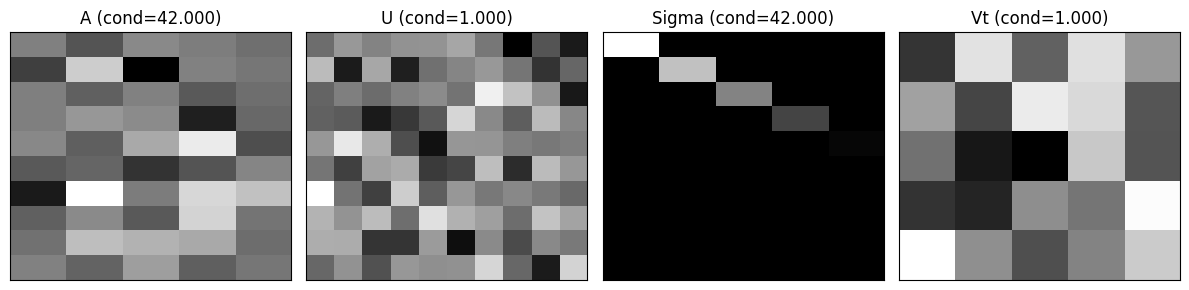

In [15]:
fig, axs = plt.subplots(1, 4, figsize=(12, 3))

mats = [A, U_rand, S, V_rand.T]
titles = [
    f"A (cond={np.linalg.cond(A):.3f})",
    f"U (cond={np.linalg.cond(U_rand):.3f})",
    f"Sigma (cond={np.linalg.cond(S):.3f})",
    f"Vt (cond={np.linalg.cond(V_rand.T):.3f})",
]

for ax, Mtx, title in zip(axs, mats, titles):
    ax.imshow(Mtx, aspect="auto", cmap="gray")
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## Exercise 14-5

Kode berikut membuat matriks acak 30 × 40 yang dihaluskan dengan konvolusi 2D Gaussian, lalu menampilkan:
- matriks awal dan matriks SVD,
- scree plot singular values dalam persen variance explained,
- empat layer rank-1 pertama dan jumlah kumulatifnya.

In [16]:
def gaussian_kernel(size=11, width=8):
    grid = np.linspace(-3, 3, size)
    X, Y = np.meshgrid(grid, grid)
    K = np.exp(-(X**2 + Y**2) / width)
    return K / np.sum(K)

raw = rng.normal(size=(30, 40))
kernel = gaussian_kernel(size=11, width=6)
A = signal.convolve2d(raw, kernel, mode="same", boundary="symm")

U, s, Vt = np.linalg.svd(A, full_matrices=True)

S = np.zeros(A.shape)
np.fill_diagonal(S, s)

var_exp = 100 * s / np.sum(s)

print("Jumlah variance explained:", np.sum(var_exp))
print("Rank A:", np.linalg.matrix_rank(A))

Jumlah variance explained: 100.0
Rank A: 30


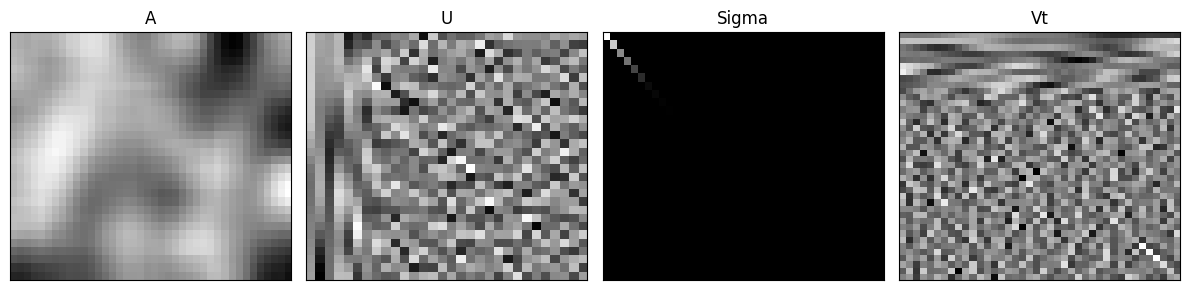

In [17]:
fig, axs = plt.subplots(1, 4, figsize=(12, 3))

for ax, Mtx, title in zip(
    axs,
    [A, U, S, Vt],
    ["A", "U", "Sigma", "Vt"]
):
    ax.imshow(Mtx, aspect="auto", cmap="gray")
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

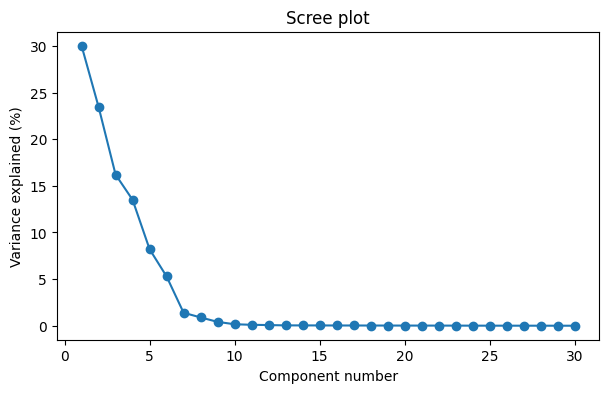

In [18]:
plt.figure(figsize=(7, 4))
plt.plot(np.arange(1, len(var_exp)+1), var_exp, marker="o")
plt.xlabel("Component number")
plt.ylabel("Variance explained (%)")
plt.title("Scree plot")
plt.show()

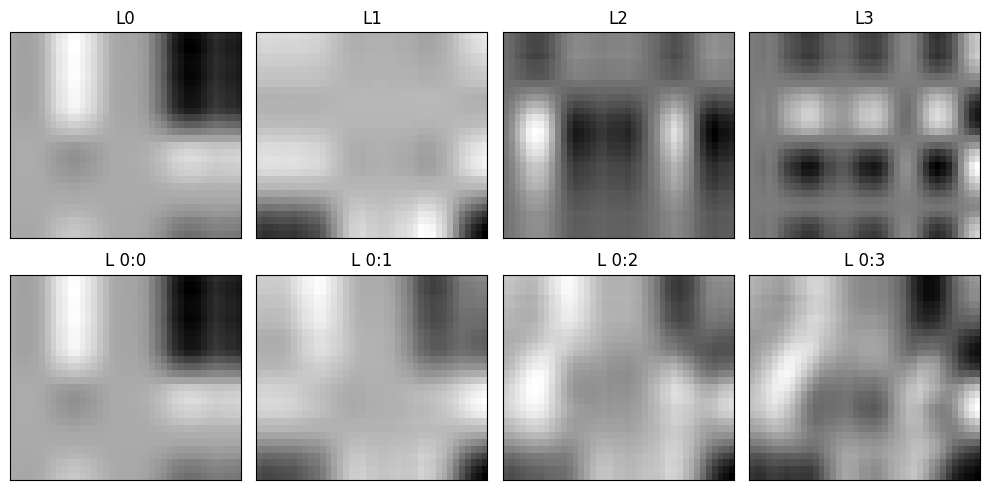

In [19]:
layers = []
cumulative_layers = []

current = np.zeros_like(A)

for i in range(4):
    layer = np.outer(U[:, i], Vt[i, :]) * s[i]
    layers.append(layer)
    current = current + layer
    cumulative_layers.append(current.copy())

fig, axs = plt.subplots(2, 4, figsize=(10, 5))

for i in range(4):
    axs[0, i].imshow(layers[i], aspect="auto", cmap="gray")
    axs[0, i].set_title(f"L{i}")
    axs[0, i].set_xticks([])
    axs[0, i].set_yticks([])

    axs[1, i].imshow(cumulative_layers[i], aspect="auto", cmap="gray")
    axs[1, i].set_title(f"L 0:{i}")
    axs[1, i].set_xticks([])
    axs[1, i].set_yticks([])

plt.tight_layout()
plt.show()

## Exercise 14-6

Pseudoinverse Moore-Penrose dapat dibuat dari SVD dengan membalik singular value yang melewati toleransi. Singular value yang terlalu kecil dianggap nol agar hasil lebih stabil secara numerik.

In [20]:
def mp_pseudoinverse(A):
    U, s, Vt = np.linalg.svd(A, full_matrices=False)
    tol = max(A.shape) * np.finfo(float).eps * np.max(s)
    s_inv = np.where(s > tol, 1/s, 0)
    return Vt.T @ np.diag(s_inv) @ U.T

A = rng.normal(size=(5, 3)) @ rng.normal(size=(3, 5))  # 5x5 rank-3

A_pinv_custom = mp_pseudoinverse(A)
A_pinv_numpy = np.linalg.pinv(A)

print("Shape A:", A.shape)
print("Rank A :", np.linalg.matrix_rank(A))
print("Jarak custom pinv vs NumPy pinv:")
print(np.linalg.norm(A_pinv_custom - A_pinv_numpy))
print("Apakah dekat:", np.allclose(A_pinv_custom, A_pinv_numpy))

Shape A: (5, 5)
Rank A : 3
Jarak custom pinv vs NumPy pinv:
1.6508152141617602e-16
Apakah dekat: True


In [21]:
# Jalankan cell ini di Google Colab untuk melihat source / dokumentasi implementasi NumPy.
np.linalg.pinv??

## Exercise 14-7

Untuk matriks tall full column-rank, pseudoinverse sama dengan left-inverse:

$$
A^+ = (A^TA)^{-1}A^T
$$

Untuk matriks wide full row-rank, pseudoinverse sama dengan right-inverse:

$$
A^+ = A^T(AA^T)^{-1}
$$

In [22]:
# Tall full column-rank
A_tall = rng.normal(size=(8, 4))

left_inv = np.linalg.inv(A_tall.T @ A_tall) @ A_tall.T
pinv_tall = np.linalg.pinv(A_tall)

print("Tall matrix")
print("Rank:", np.linalg.matrix_rank(A_tall))
print("Jarak left-inverse vs pinv:", np.linalg.norm(left_inv - pinv_tall))
print("Sama:", np.allclose(left_inv, pinv_tall))
print()

# Wide full row-rank
A_wide = rng.normal(size=(4, 8))

right_inv = A_wide.T @ np.linalg.inv(A_wide @ A_wide.T)
pinv_wide = np.linalg.pinv(A_wide)

print("Wide matrix")
print("Rank:", np.linalg.matrix_rank(A_wide))
print("Jarak right-inverse vs pinv:", np.linalg.norm(right_inv - pinv_wide))
print("Sama:", np.allclose(right_inv, pinv_wide))

Tall matrix
Rank: 4
Jarak left-inverse vs pinv: 5.235589726726011e-16
Sama: True

Wide matrix
Rank: 4
Jarak right-inverse vs pinv: 7.163798886543621e-16
Sama: True


## Example 14-8

Gunakan matriks 2 × 2 dari awal Chapter 13, lalu hitung pseudoinverse dari eigenvector.

Untuk eigenvector sebagai vektor kolom, bentuk skalar yang benar adalah:

$$
v^+v = 1
$$

Sedangkan \(vv^+\) menghasilkan matriks proyeksi, bukan skalar.

Identitas yang diuji:

$$
v^+Av = \lambda v^+v
$$

$$
Avv^+ = \lambda vv^+
$$

In [23]:
A = np.array([
    [1, 2],
    [3, 4]
], dtype=float)

evals, evecs = np.linalg.eig(A)

for i in range(len(evals)):
    lam = evals[i]
    v = evecs[:, [i]]      # eigenvector sebagai kolom
    v_pinv = np.linalg.pinv(v)

    scalar_identity_left = v_pinv @ v

    lhs1 = v_pinv @ A @ v
    rhs1 = lam * (v_pinv @ v)

    lhs2 = A @ v @ v_pinv
    rhs2 = lam * (v @ v_pinv)

    print(f"Eigenpair {i+1}")
    print("lambda:", lam)
    print("v+v:")
    print(scalar_identity_left)
    print("Jarak v+Av dan lambda v+v:", np.linalg.norm(lhs1 - rhs1))
    print("Jarak Avv+ dan lambda vv+:", np.linalg.norm(lhs2 - rhs2))
    print()

Eigenpair 1
lambda: -0.3722813232690143
v+v:
[[1.]]
Jarak v+Av dan lambda v+v: 5.551115123125783e-17
Jarak Avv+ dan lambda vv+: 4.8074067159589095e-17

Eigenpair 2
lambda: 5.372281323269014
v+v:
[[1.]]
Jarak v+Av dan lambda v+v: 0.0
Jarak Avv+ dan lambda vv+: 4.577566798522237e-16

